# Análise Exploratória e Clusterização RFM em Ecossistemas de E-commerce de Médio Porte

### Sobre o projeto

Este projeto é uma intersecção entre o Product Design e a Análise de Dados, focando no estágio de retenção e engajamento das Métricas Piratas (AARRR). 

O objetivo central é transformar dados transacionais brutos de e-commerces de médio porte em inteligência acionável para o negócio.

## Etapa 1 - Preparação

#### 1.1 - Importação das bibliotecas

In [50]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt

#### 1.2 - Gerar a base de dados

In [51]:
# Configuração de reprodutibilidade
np.random.seed(42)

# Criando 1000 registros de transações
n_rows = 1000
data = {
    'Transaction_ID': range(1, n_rows + 1),
    'Customer_ID': np.random.choice([101, 102, 103, 104, 105, np.nan], n_rows), # Dados ausentes
    'Date': [datetime(2025, 1, 1) + timedelta(days=np.random.randint(0, 400)) for _ in range(n_rows)],
    'Product_Category': np.random.choice(['Eletrônicos', 'Moda', 'Casa', 'Beleza'], n_rows),
    'Order_Value': np.random.normal(150, 50, n_rows).round(2),
    'Status': np.random.choice(['Concluído', 'Cancelado', 'Pendente'], n_rows, p=[0.8, 0.1, 0.1])
}

df = pd.DataFrame(data)

# Inserindo "sujeira" proposital
df.iloc[0:10, 4] = -50.0  # Valores negativos impossíveis
df.iloc[20:30, 4] = 15000.0 # Outliers extremos
df = pd.concat([df, df.iloc[:15]], ignore_index=True) # Duplicatas

df.to_csv('ecommerce_data_raw.csv', index=False)

print(df.head(10))
df.info()

   Transaction_ID  Customer_ID       Date Product_Category  Order_Value  \
0               1        104.0 2025-05-30             Casa        -50.0   
1               2        105.0 2025-10-04             Casa        -50.0   
2               3        103.0 2025-07-17             Casa        -50.0   
3               4        105.0 2025-03-11             Casa        -50.0   
4               5        105.0 2025-04-22           Beleza        -50.0   
5               6        102.0 2025-01-04           Beleza        -50.0   
6               7        103.0 2025-12-16           Beleza        -50.0   
7               8        103.0 2025-11-27             Moda        -50.0   
8               9        103.0 2025-11-14             Moda        -50.0   
9              10        105.0 2025-12-16             Moda        -50.0   

      Status  
0  Concluído  
1  Concluído  
2  Concluído  
3  Concluído  
4  Concluído  
5  Concluído  
6  Concluído  
7  Concluído  
8   Pendente  
9  Concluído  
<class 'p

## Etapa 2 - Limpeza de Dados

#### 2.1 - Tratamento de Nulos

In [52]:
# Verificando a quantidade de valores nulos por coluna
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Calculando a porcentagem de dados ausentes em Customer_ID
missing_cid = df['Customer_ID'].isnull().mean() * 100
print(f"\nPorcentagem de transações sem Customer_ID: {missing_cid:.2f}%")

Valores nulos por coluna:
Transaction_ID        0
Customer_ID         156
Date                  0
Product_Category      0
Order_Value           0
Status                0
dtype: int64

Porcentagem de transações sem Customer_ID: 15.37%


In [53]:
# Removendo registros onde o Customer_ID é nulo
df.dropna(subset=['Customer_ID'], inplace=True)

print(f"Registros restantes após a remoção de nulos: {len(df)}")

Registros restantes após a remoção de nulos: 859


#### 2.2 - Tratamento de Registros Duplicados

In [54]:
# Contando o total de linhas duplicadas (considerando todas as colunas)
total_duplicadas = df.duplicated().sum()

print(f"Foram encontrados {total_duplicadas} registros exatamente iguais.")

# Visualizando algumas dessas linhas duplicadas para conferência
if total_duplicadas > 0:
    print("\nExemplo de linhas duplicadas:")
    display(df[df.duplicated(keep=False)].head(5))

Foram encontrados 14 registros exatamente iguais.

Exemplo de linhas duplicadas:


,Transaction_ID,Customer_ID,Date,Product_Category,Order_Value,Status
0,1,104.0,2025-05-30,Casa,-50.0,Concluído
1,2,105.0,2025-10-04,Casa,-50.0,Concluído
2,3,103.0,2025-07-17,Casa,-50.0,Concluído
3,4,105.0,2025-03-11,Casa,-50.0,Concluído
4,5,105.0,2025-04-22,Beleza,-50.0,Concluído


In [55]:
# Removendo as duplicatas
df.drop_duplicates(inplace=True)

print(f"Limpeza concluída. Registros únicos restantes: {len(df)}")

Limpeza concluída. Registros únicos restantes: 845


#### 2.3 - Limpeza de Outliers e Erros

In [56]:
# 1. Removendo valores negativos (erros de sistema/lógicos)
print(f"Registros antes de remover negativos: {len(df)}")
df = df[df['Order_Value'] > 0]
print(f"Registros após remover negativos: {len(df)}")

# 2. Identificando e tratando Outliers Extremos com IQR
Q1 = df['Order_Value'].quantile(0.25)
Q3 = df['Order_Value'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

# Filtrando o DataFrame para manter apenas pedidos dentro do limite estatístico
outliers_count = len(df[df['Order_Value'] > limite_superior])
df = df[df['Order_Value'] <= limite_superior]

print(f"\nLimite superior calculado: R$ {limite_superior:.2f}")
print(f"Foram removidos {outliers_count} outliers extremos (ex: os valores de R$ 15.000).")
print(f"Tamanho final do dataset limpo: {len(df)}")

Registros antes de remover negativos: 845
Registros após remover negativos: 834

Limite superior calculado: R$ 288.64
Foram removidos 9 outliers extremos (ex: os valores de R$ 15.000).
Tamanho final do dataset limpo: 825


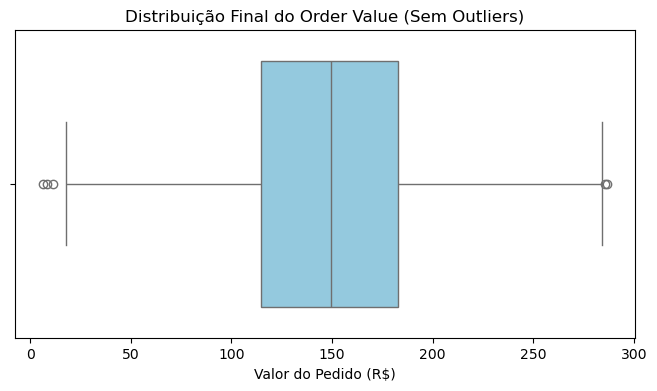

In [57]:
# Visualização da Distribuição do valor da compra sem outliers

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Order_Value'], color='skyblue')
plt.title("Distribuição Final do Order Value (Sem Outliers)")
plt.xlabel("Valor do Pedido (R$)")
plt.show()

#### 2.4 - Tipagem

In [58]:
# 1. Convertendo a coluna Date para o formato datetime
df['Date'] = pd.to_datetime(df['Date'])

# 2. Convertendo colunas de texto repetitivo para o tipo 'category'
df['Product_Category'] = df['Product_Category'].astype('category')
df['Status'] = df['Status'].astype('category')

# 3. Garantindo que o Customer_ID seja inteiro
df['Customer_ID'] = df['Customer_ID'].astype(int)

# Verificação
print("Novos tipos das colunas:")
print(df.dtypes)

Novos tipos das colunas:
Transaction_ID               int64
Customer_ID                  int64
Date                datetime64[ns]
Product_Category          category
Order_Value                float64
Status                    category
dtype: object


## Etapa 3 - Análise Exploratória (EDA)

#### 3.1 - Visão Temporal

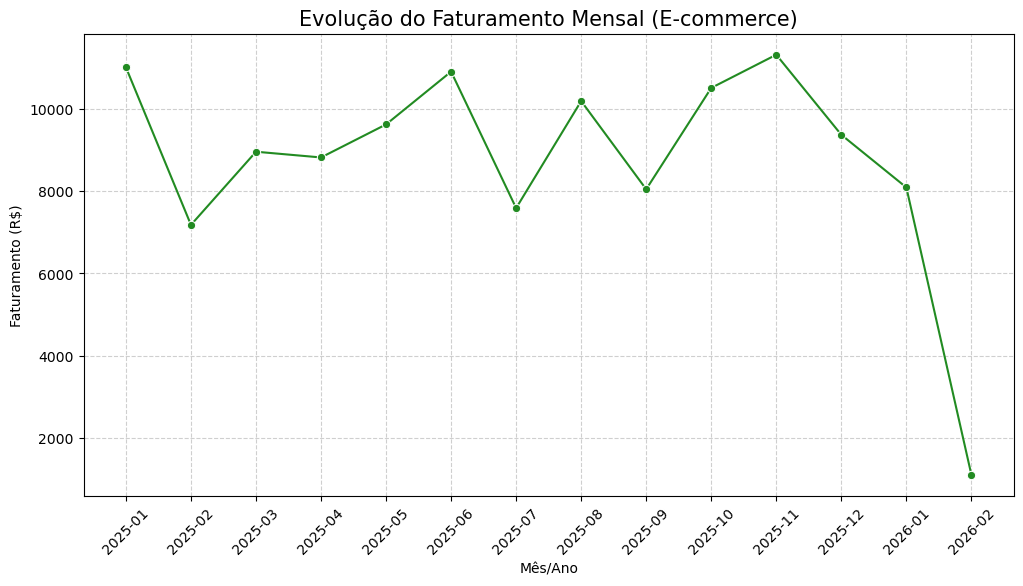

Resumo Mensal:


,Mes,Faturamento_Total,Qtd_Pedidos
0,2025-01,11015.68,72
1,2025-02,7182.35,49
2,2025-03,8962.76,62
3,2025-04,8823.03,58
4,2025-05,9626.96,62
5,2025-06,10911.65,72
6,2025-07,7591.04,54
7,2025-08,10195.36,68
8,2025-09,8049.01,57
9,2025-10,10515.22,70


In [59]:
# 1. Criando colunas de Ano e Mês para facilitar o agrupamento
df['Year_Month'] = df['Date'].dt.to_period('M').astype(str)

# 2. Agrupando os dados por mês
vendas_mensais = df.groupby('Year_Month').agg({
    'Order_Value': 'sum',
    'Transaction_ID': 'count'
}).reset_index()

vendas_mensais.columns = ['Mes', 'Faturamento_Total', 'Qtd_Pedidos']

# 3. Visualização: Evolução do Faturamento
plt.figure(figsize=(12, 6))
sns.lineplot(data=vendas_mensais, x='Mes', y='Faturamento_Total', marker='o', color='forestgreen')

plt.title('Evolução do Faturamento Mensal (E-commerce)', fontsize=15)
plt.xlabel('Mês/Ano')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Exibindo a tabela com os números para conferência
print("Resumo Mensal:")
display(vendas_mensais)

#### 3.2 - Mix de Produtos

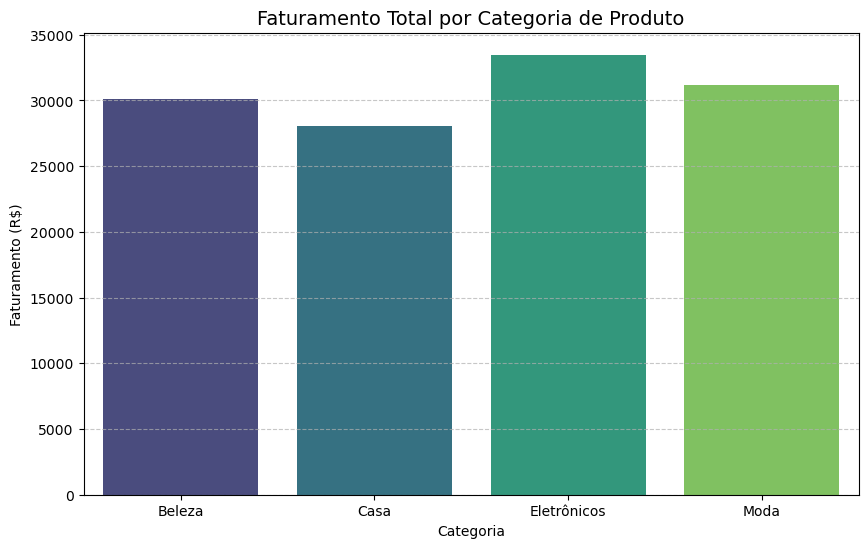

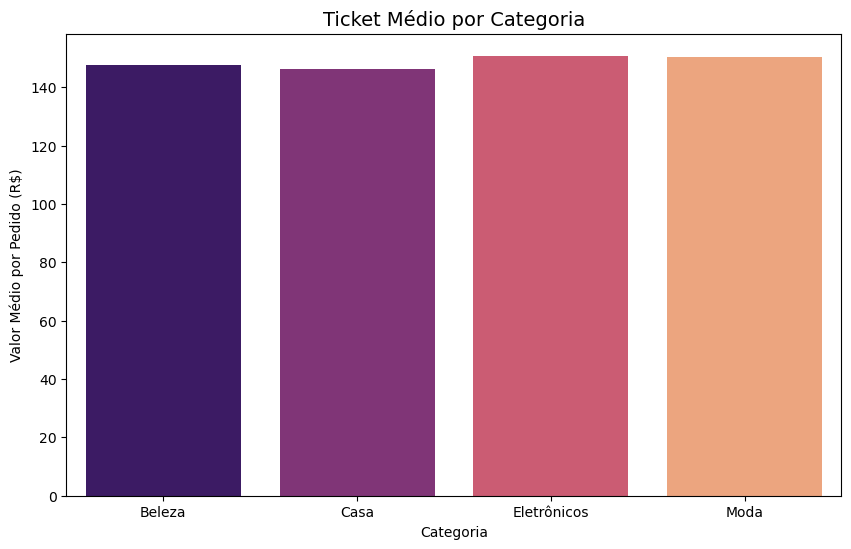

In [60]:
# 1. Agrupando por Categoria
mix_produtos = df.groupby('Product_Category', observed=False).agg({
    'Order_Value': ['sum', 'count', 'mean']
}).reset_index()

# Ajustando o nome das colunas
mix_produtos.columns = ['Categoria', 'Faturamento_Total', 'Qtd_Vendas', 'Ticket_Médio']
mix_produtos = mix_produtos.sort_values(by='Faturamento_Total', ascending=False)

# 2. Visualização: Faturamento por Categoria
plt.figure(figsize=(10, 6))
sns.barplot(
    data=mix_produtos, 
    x='Categoria', 
    y='Faturamento_Total', 
    hue='Categoria', 
    palette='viridis', 
    legend=False
)

plt.title('Faturamento Total por Categoria de Produto', fontsize=14)
plt.ylabel('Faturamento (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Visualização: Ticket Médio por Categoria
plt.figure(figsize=(10, 6))
sns.barplot(
    data=mix_produtos, 
    x='Categoria', 
    y='Ticket_Médio', 
    hue='Categoria', 
    palette='magma', 
    legend=False
)

plt.title('Ticket Médio por Categoria', fontsize=14)
plt.ylabel('Valor Médio por Pedido (R$)')
plt.show()

#### 3.3 - Saúde do Negócio

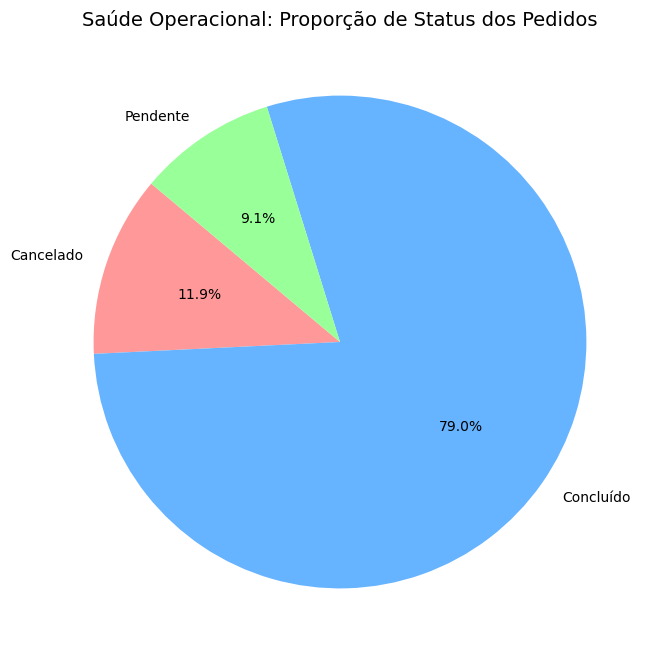

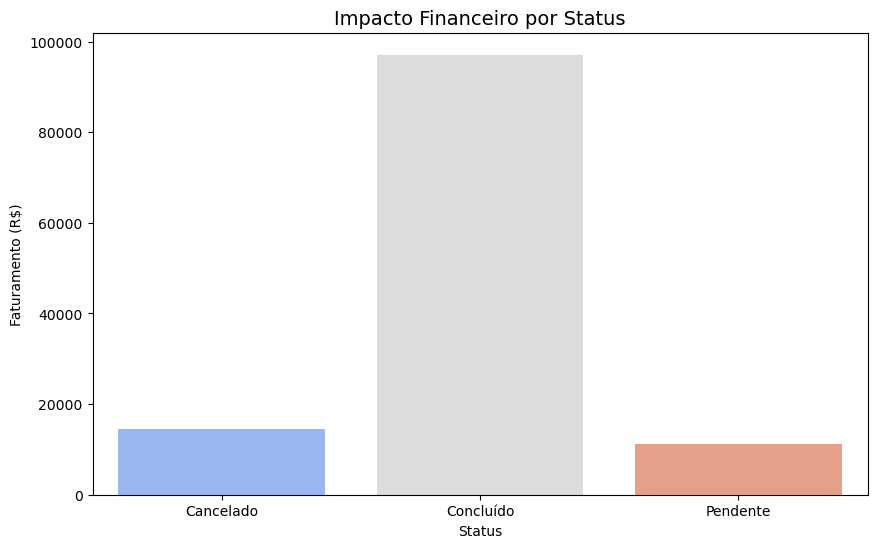

Resumo de Saúde do Negócio:


,Status,Qtd_Pedidos,Faturamento_Potencial,Percentual
0,Cancelado,98,"R$ 14,451.86",11.88%
1,Concluído,652,"R$ 97,101.42",79.03%
2,Pendente,75,"R$ 11,214.25",9.09%


In [61]:
# 1. Analisando a distribuição do Status dos Pedidos
status_saude = df.groupby('Status', observed=False).agg({
    'Transaction_ID': 'count',
    'Order_Value': 'sum'
}).reset_index()

status_saude.columns = ['Status', 'Qtd_Pedidos', 'Faturamento_Potencial']

# 2. Calculando a porcentagem (Taxa de Conversão e Cancelamento)
status_saude['Percentual'] = (status_saude['Qtd_Pedidos'] / status_saude['Qtd_Pedidos'].sum() * 100).round(2)

# 3. Visualização: Distribuição de Status (Gráfico de Pizza para Saúde Geral)
plt.figure(figsize=(8, 8))
plt.pie(
    status_saude['Qtd_Pedidos'], 
    labels=status_saude['Status'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999','#66b3ff','#99ff99']
)
plt.title('Saúde Operacional: Proporção de Status dos Pedidos', fontsize=14)
plt.show()

# 4. Visualização: Faturamento Concluído vs. Cancelado vs. Pendente
plt.figure(figsize=(10, 6))
sns.barplot(
    data=status_saude, 
    x='Status', 
    y='Faturamento_Potencial', 
    hue='Status', 
    palette='coolwarm', 
    legend=False
)

plt.title('Impacto Financeiro por Status', fontsize=14)
plt.ylabel('Faturamento (R$)')
plt.show()

# Exibindo o resumo numérico
print("Resumo de Saúde do Negócio:")
display(status_saude.style.format({
    'Faturamento_Potencial': 'R$ {:,.2f}',
    'Percentual': '{:.2f}%'
}))

## Etapa 4 - Análise RFM

#### 4.1 - Recência

Data de referência para o cálculo: 2026-02-04


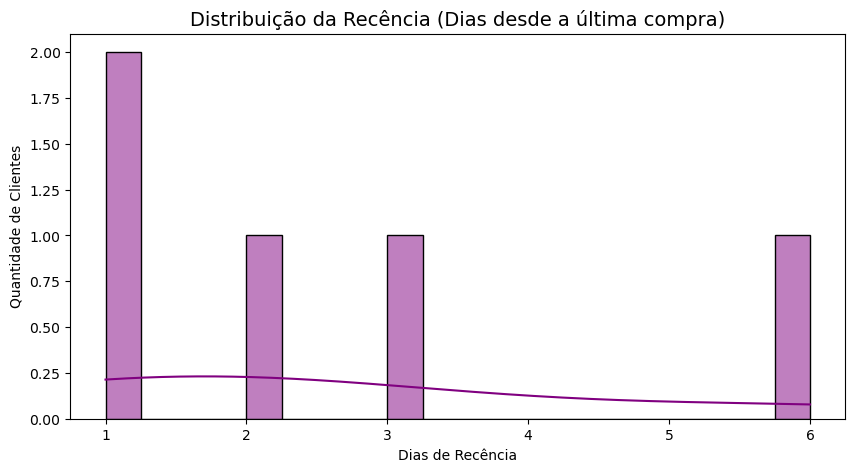

Tabela de Recência (Top 5):


,Customer_ID,Recencia
0,101,2
1,102,1
2,103,1
3,104,6
4,105,3


In [62]:
# 1. Definindo a data de referência (Snapshot Date)
data_referencia = df['Date'].max() + pd.Timedelta(days=1)

print(f"Data de referência para o cálculo: {data_referencia.date()}")

# 2. Calculando a Recência por Cliente
recencia_df = df.groupby('Customer_ID').agg({
    'Date': lambda x: (data_referencia - x.max()).days
}).reset_index()

# Renomeando as colunas
recencia_df.columns = ['Customer_ID', 'Recencia']

# 3. Visualização da Distribuição da Recência
plt.figure(figsize=(10, 5))
sns.histplot(recencia_df['Recencia'], bins=20, kde=True, color='purple')

plt.title('Distribuição da Recência (Dias desde a última compra)', fontsize=14)
plt.xlabel('Dias de Recência')
plt.ylabel('Quantidade de Clientes')
plt.show()

# Exibindo os primeiros clientes
print("Tabela de Recência (Top 5):")
display(recencia_df.head())

#### 4.2 - Frequência

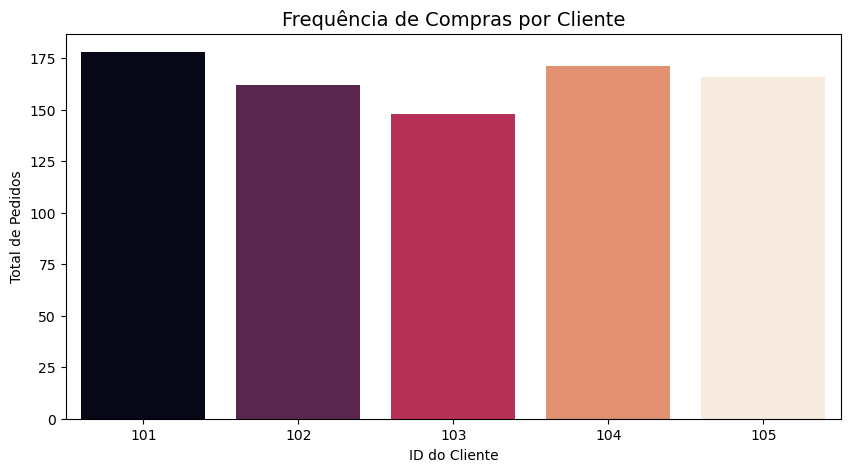

Tabela RF (Recência e Frequência):


,Customer_ID,Recencia,Frequencia
0,101,2,178
3,104,6,171
4,105,3,166
1,102,1,162
2,103,1,148


In [63]:
# 1. Calculando a Frequência por Cliente
frequencia_df = df.groupby('Customer_ID').agg({
    'Transaction_ID': 'count'
}).reset_index()

# Renomeando as colunas
frequencia_df.columns = ['Customer_ID', 'Frequencia']

# 2. Unindo a Frequência com a tabela de Recência (criando a base RFM)
rfm_df = pd.merge(recencia_df, frequencia_df, on='Customer_ID')

# 3. Visualização da Frequência (Gráfico de Barras)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=rfm_df, 
    x='Customer_ID', 
    y='Frequencia', 
    hue='Customer_ID', 
    palette='rocket', 
    legend=False
)

plt.title('Frequência de Compras por Cliente', fontsize=14)
plt.xlabel('ID do Cliente')
plt.ylabel('Total de Pedidos')
plt.show()

# Exibindo os dados consolidados até agora
print("Tabela RF (Recência e Frequência):")
display(rfm_df.sort_values(by='Frequencia', ascending=False))

#### 4.3 - Monetário

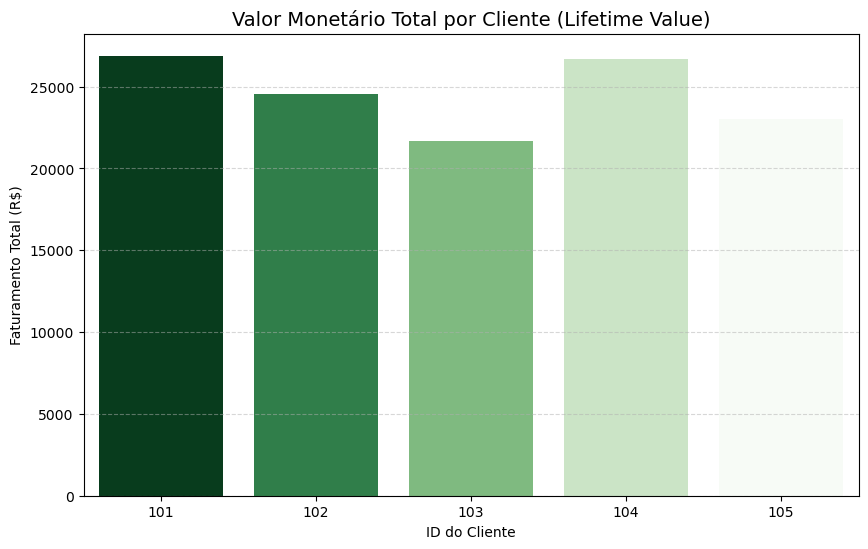

Tabela RFM Final (Recência, Frequência e Monetário):


,Customer_ID,Recencia,Frequencia,Monetario
0,101,2 dias,178,"R$ 26,889.17"
3,104,6 dias,171,"R$ 26,667.75"
1,102,1 dias,162,"R$ 24,542.02"
4,105,3 dias,166,"R$ 23,010.74"
2,103,1 dias,148,"R$ 21,657.85"


In [64]:
# 1. Calculando o Valor Monetário por Cliente
monetario_df = df.groupby('Customer_ID').agg({
    'Order_Value': 'sum'
}).reset_index()

# Renomeando as colunas
monetario_df.columns = ['Customer_ID', 'Monetario']

# 2. Unindo o Monetário com a tabela RF que já tínhamos (R e F)
rfm_completo = pd.merge(rfm_df, monetario_df, on='Customer_ID')

# 3. Visualização: Valor Total Gasto por Cliente
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rfm_completo, 
    x='Customer_ID', 
    y='Monetario', 
    hue='Customer_ID', 
    palette='Greens_r', 
    legend=False
)

plt.title('Valor Monetário Total por Cliente (Lifetime Value)', fontsize=14)
plt.ylabel('Faturamento Total (R$)')
plt.xlabel('ID do Cliente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Exibindo a Tabela RFM Final Consolidada
print("Tabela RFM Final (Recência, Frequência e Monetário):")
display(rfm_completo.sort_values(by='Monetario', ascending=False).style.format({
    'Monetario': 'R$ {:,.2f}',
    'Recencia': '{:.0f} dias'
}))

#### 4.4 - Criação de Scores

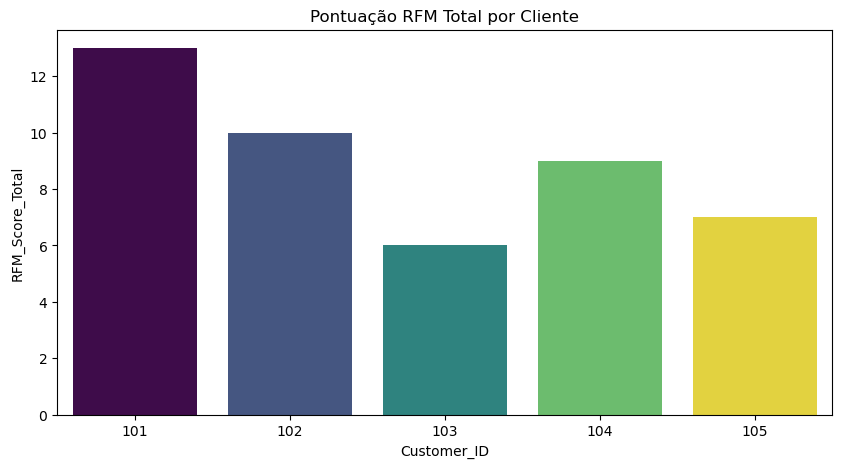

Tabela com Scores calculados:


,Customer_ID,Recencia,Frequencia,Monetario,RFM_ID,RFM_Score_Total
0,101,2,178,26889.17,355,13
1,102,1,162,24542.02,523,10
2,103,1,148,21657.85,411,6
3,104,6,171,26667.75,144,9
4,105,3,166,23010.74,232,7


In [65]:
# 1. Criando os Scores de 1 a 5

# Recência: Menor é melhor (labels 5 a 1)
rfm_completo['R_Score'] = pd.qcut(
    rfm_completo['Recencia'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]
)

# Frequência: Maior é melhor (labels 1 a 5)
rfm_completo['F_Score'] = pd.qcut(
    rfm_completo['Frequencia'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]
)

# Monetário: Maior é melhor (labels 1 a 5)
rfm_completo['M_Score'] = pd.qcut(
    rfm_completo['Monetario'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]
)

# 2. Criando a pontuação total e a versão "texto" (ex: 555)
rfm_completo['RFM_Score_Total'] = (
    rfm_completo['R_Score'].astype(int) + 
    rfm_completo['F_Score'].astype(int) + 
    rfm_completo['M_Score'].astype(int)
)

rfm_completo['RFM_ID'] = (
    rfm_completo['R_Score'].astype(str) + 
    rfm_completo['F_Score'].astype(str) + 
    rfm_completo['M_Score'].astype(str)
)

# 3. Visualização rápida dos Scores
plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_completo, x='Customer_ID', y='RFM_Score_Total', hue='Customer_ID', palette='viridis', legend=False)
plt.title('Pontuação RFM Total por Cliente')
plt.show()

print("Tabela com Scores calculados:")
display(rfm_completo[['Customer_ID', 'Recencia', 'Frequencia', 'Monetario', 'RFM_ID', 'RFM_Score_Total']])

#### 4.5 - Classificação dos Clientes

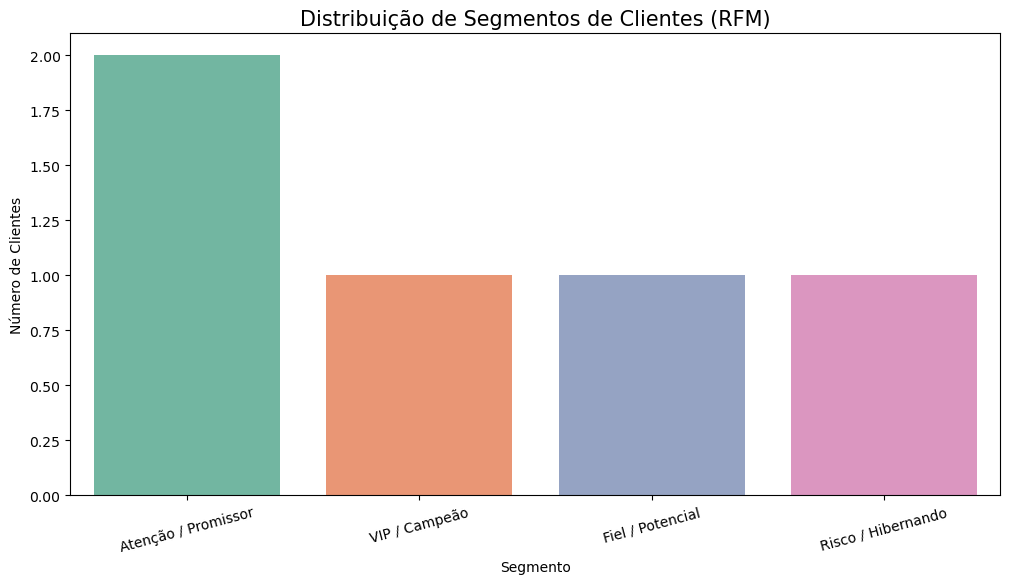

Relatório Final de Segmentação:


,Customer_ID,RFM_ID,RFM_Score_Total,Segmento
0,101,355,13,VIP / Campeão
1,102,523,10,Fiel / Potencial
3,104,144,9,Atenção / Promissor
4,105,232,7,Atenção / Promissor
2,103,411,6,Risco / Hibernando


In [66]:
# 1. Definindo a função de segmentação
def segmentar_cliente(df):
    score = df['RFM_Score_Total']
    
    if score >= 13:
        return 'VIP / Campeão'
    elif score >= 10:
        return 'Fiel / Potencial'
    elif score >= 7:
        return 'Atenção / Promissor'
    elif score >= 5:
        return 'Risco / Hibernando'
    else:
        return 'Perdido'

# 2. Aplicando a segmentação
rfm_completo['Segmento'] = rfm_completo.apply(segmentar_cliente, axis=1)

# 3. Visualização: Distribuição dos Segmentos
plt.figure(figsize=(12, 6))
segmento_counts = rfm_completo['Segmento'].value_counts().reset_index()
segmento_counts.columns = ['Segmento', 'Quantidade']

sns.barplot(
    data=segmento_counts, 
    x='Segmento', 
    y='Quantidade', 
    hue='Segmento', 
    palette='Set2', 
    legend=False
)

plt.title('Distribuição de Segmentos de Clientes (RFM)', fontsize=15)
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=15)
plt.show()

# Exibindo o resultado final consolidado
print("Relatório Final de Segmentação:")
display(rfm_completo[['Customer_ID', 'RFM_ID', 'RFM_Score_Total', 'Segmento']].sort_values(by='RFM_Score_Total', ascending=False))

## Etapa 5 - Conclusão

A análise realizada permitiu transformar dados brutos de e-commerce em inteligência estratégica, começando pela rigorosa higienização do dataset, onde foram tratados erros lógicos e outliers que distorceriam os resultados financeiros. Ao avançar para a análise exploratória, mapeamos o desempenho das categorias de produtos e a saúde operacional do negócio, identificando gargalos em pedidos não concluídos. Por fim, a implementação da metodologia RFM segmentou a base de clientes de forma acionável, permitindo que a empresa diferencie o atendimento entre clientes VIP e aqueles que necessitam de campanhas de reativação. O resultado final é um dataset confiável e um plano de segmentação pronto para orientar decisões de marketing e fidelização de clientes.